<a href="https://colab.research.google.com/github/armybonita/Good-Energy-Intelligence-Score/blob/main/%EB%94%A5%EB%9F%AC%EB%8B%9D%EC%8B%A4%EC%8A%B5_RNN_ipynb%EC%9D%98_%EC%82%AC%EB%B3%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part 1: Time-Series Regression via LSTM

본 파트는 시계열(Time-Series) 데이터 내재된 시간적 의존성(Temporal Dependency)을 모델링하기 위해 LSTM(Long Short-Term Memory) 아키텍처를 도입한다.

금융공학적 모델링에서 주가와 같은 비정상성(Non-stationary) 시계열 데이터를 다룰 때, 과거의 Sequence $X = \{x_{t-k}, \dots, x_{t-1}, x_t\}$ 정보를 기반으로 미래의 시점 $x_{t+1}$의 Continuous Value를 예측하는 것은 핵심적인 과제다.

표준 RNN이 지닌 장기 의존성(Long-term Dependencies) 학습의 한계와 기울기 소실(Vanishing Gradient) 문제를 해결하기 위해 도입된 Gating Mechanism의 수학적 구조를 이해하고, 회귀(Regression) 문제의 목적 함수인 $\mathcal{L}_{MSE}$를 최적화하는 전체 파이프라인을 구축한다.

![image](https://snowdeer.github.io/assets/machine-learning/046.png)

## 시계열 데이터셋 수집 및 특성 분석

yfinance API를 활용하여 실제 금융 시장의 주가 데이터를 수집한다.

단변량 시계열(Univariate Time-Series)을 가정하고 종가(Close Price)를 Target Variable로 설정한다.

금융 시계열 데이터는 추세(Trend)와 이분산성(Heteroskedasticity)을 포함하며 높은 노이즈를 동반하므로, 신경망의 입력으로 주입하기 전 데이터의 분포와 스케일을 분석하는 과정이 선행되어야 한다.

In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

def fetch_and_analyze_financial_data(ticker: str, start_date: str, end_date: str) -> pd.DataFrame:
    """
    지정된 티커의 주가 데이터를 다운로드하고 종가(Close) 데이터를 반환한다.
    """
    df = yf.download(ticker, start=start_date, end=end_date)

    # 데이터 정합성 검증
    if df.empty:
        raise ValueError(f"No data fetched for {ticker}. Check ticker or date range.")
    assert df.isnull().sum().sum() == 0, "Missing values detected in the dataset."

    # 단변량 시계열 분석을 위한 종가 추출
    close_data = df[['Close']].copy()

    return close_data

### 데이터 수집 (종목, 시작일자, 종료일자)

In [2]:
# 1. 데이터 수집
ticker_symbol = 'AAPL'
start_idx = '2015-01-01'
end_idx = '2023-12-31'

ts_data = fetch_and_analyze_financial_data(ticker_symbol, start_idx, end_idx)

/tmp/ipykernel_2967/3911499138.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


### 기초 통계량 확인

In [3]:
# 2. 기초 통계량 확인
print(f"[{ticker_symbol}] Time-Series Data Description:")
print(ts_data.describe())

[AAPL] Time-Series Data Description:
Price         Close
Ticker         AAPL
count   2264.000000
mean      81.318619
std       55.938537
min       20.584820
25%       32.784017
50%       51.172964
75%      138.887669
max      196.073105


### 데이터 시각화 (EDA)

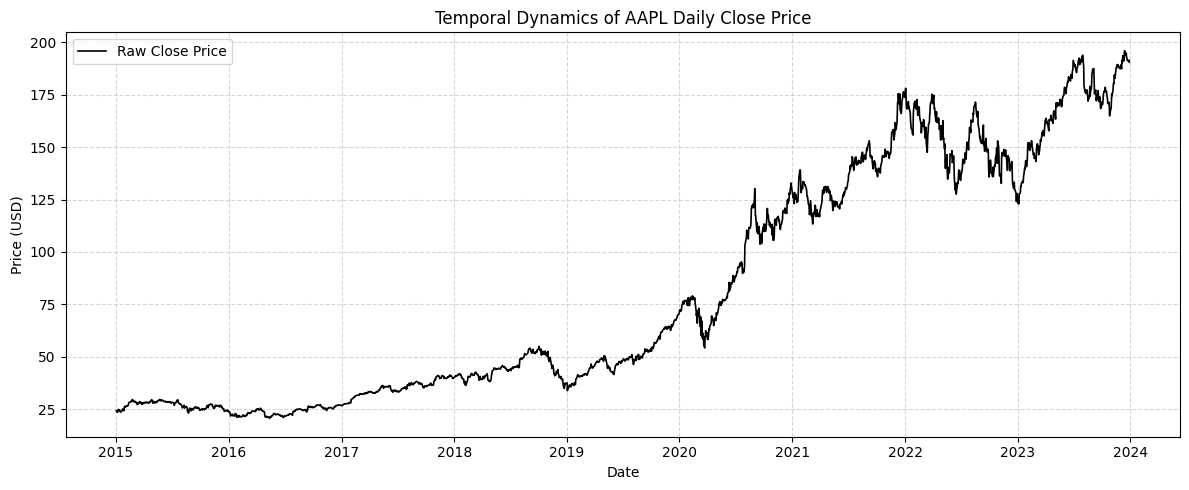

In [4]:
plt.figure(figsize=(12, 5))
plt.plot(ts_data.index, ts_data['Close'], label='Raw Close Price', color='k', linewidth=1.2)
plt.title(f"Temporal Dynamics of {ticker_symbol} Daily Close Price")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 시퀀스 데이터 전처리 (Normalization 및 Look-back Window)

신경망, 특히 LSTM과 같은 Gating 메커니즘을 포함하는 순환 신경망 구조는 입력 데이터의 스케일에 극도로 민감하다.

내부적으로 $\sigma(x)$ 및 $\tanh(x)$ 활성화 함수를 통과하므로, 스케일링되지 않은 Raw Data를 주입할 경우 기울기 소실(Vanishing Gradient) 또는 폭발(Exploding Gradient) 현상이 발생하여 $\mathcal{L}_{MSE}$의 최적화가 불가능해진다.

따라서 Min-Max 정규화를 통해 입력 공간을 $[0, 1]$ 또는 $[-1, 1]$로 투영해야 한다.

$$x_{t}^{(norm)} = \frac{x_t - \min(\mathcal{X}_{train})}{\max(\mathcal{X}_{train}) - \min(\mathcal{X}_{train})}$$

또한, 시계열 예측을 지도 학습(Supervised Learning) 문제로 변환하기 위해 슬라이딩 윈도우(Sliding Window) 기법을 적용한다.

Look-back window size를 $W$라 할 때, 특정 시점 $t$의 입력 $X_t$와 정답 레이블 $y_t$는 다음과 같이 정의된다.

$$X_t = [x_{t-W}, x_{t-W+1}, \dots, x_{t-1}], \quad y_t = x_t$$

**주의**: 스케일러(Scaler)를 피팅할 때, 미래 시점의 정보가 과거로 누수되는 Look-ahead Bias를 엄격히 차단해야만 유의미한 딥러닝 모델을 만들 수 있다.

만일 하지 않는 경우 미래 시점을 이미 알고 있는 상태에서 예측을 수행하기 때문에 train 및 test 단계에서는 잘 작동할 수도 있으나, 실제 모델로 활용하기 어렵다.

즉, 정규화 파라미터(min, max)는 오직 Training Set에서만 추출되어야 하며, Test Set은 해당 파라미터를 그대로 적용하여 변환(Transform)만 수행해야 한다.

In [5]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from typing import Tuple

def preprocess_time_series(
    df: pd.DataFrame,
    train_ratio: float = 0.8,
    look_back: int = 60
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, MinMaxScaler]:
    """
    Look-ahead Bias를 방지하기 위해 분할 후 정규화를 수행하며,
    Sliding Window 기법을 통해 (N, W, C) 형태의 3D 텐서 입력을 구성한다.
    """
    raw_data = df['Close'].values.reshape(-1, 1)

    # 1. Train-Test Split (Chronological Order)
    split_idx = int(len(raw_data) * train_ratio)
    train_data = raw_data[:split_idx]
    test_data = raw_data[split_idx:]

    # 2. Normalization (Fit strictly on train_data)
    scaler = MinMaxScaler(feature_range=(0, 1))
    train_scaled = scaler.fit_transform(train_data)
    test_scaled = scaler.transform(test_data)

    # 3. Sliding Window Sequence Generation
    def create_sequences(data: np.ndarray, window_size: int) -> Tuple[np.ndarray, np.ndarray]:
        X, y = [], []
        for i in range(len(data) - window_size):
            X.append(data[i : i + window_size, 0])
            y.append(data[i + window_size, 0])
        return np.array(X), np.array(y)

    X_train, y_train = create_sequences(train_scaled, look_back)
    X_test, y_test = create_sequences(test_scaled, look_back)

    # RNN/LSTM 입력 차원(N, W, C)을 맞추기 위한 Reshape (C=1)
    X_train = np.expand_dims(X_train, axis=-1)
    X_test = np.expand_dims(X_test, axis=-1)
    y_train = np.expand_dims(y_train, axis=-1)
    y_test = np.expand_dims(y_test, axis=-1)

    return X_train, y_train, X_test, y_test, scaler

위 코드는 데이터를 Train 과 test 셋으로 나누는 작업을 수행한다.

실제 데이터는 앞선 시각화와 같이 역사적인 종가(close) 데이터만이 존재하므로 MLP와 CNN 실습에서와 같이 입출력이 정의되기 이전이다.

따라서 X와 Y를 수동으로 나누어주는 작업이 수행되어야 한다.



![image](https://www.mdpi.com/remotesensing/remotesensing-13-03328/article_deploy/html/images/remotesensing-13-03328-g003-550.jpg)

In [6]:
# 실행 로직
WINDOW_SIZE = 60 # 60일의 과거 데이터를 기반으로 1일의 미래 예측

## 변경 가능한 파라미터, 120일, 100일 등 원하는 값으로 설정 가능

X_train_seq, y_train_seq, X_test_seq, y_test_seq, price_scaler = preprocess_time_series(
    ts_data,
    train_ratio=0.8,
    look_back=WINDOW_SIZE
)

print(f"X_train shape: {X_train_seq.shape}") # (N_train, 60, 1)
print(f"y_train shape: {y_train_seq.shape}") # (N_train, 1)
print(f"X_test shape: {X_test_seq.shape}")   # (N_test, 60, 1)
print(f"y_test shape: {y_test_seq.shape}")   # (N_test, 1)

X_train shape: (1751, 60, 1)
y_train shape: (1751, 1)
X_test shape: (393, 60, 1)
y_test shape: (393, 1)


## PyTorch Dataset 및 DataLoader 구축

생성된 3차원 Numpy 배열 형태의 시퀀스 데이터를 PyTorch 기반 신경망의 입력으로 활용하기 위해 torch.utils.data.Dataset 및 DataLoader 객체로 변경한.


시계열 예측에서 시퀀스 내부의 순서(Look-back Window 내의 시간적 의존성)는 엄격히 보존되어야 하나, 학습 시 미니 배치 간의 순서는 상관관계(Correlation)를 끊고 일반화 성능을 높이기 위해 무작위로 섞는 것(Shuffling)이 일반적이다.

단, 검증 및 테스트 데이터셋은 성능 평가의 일관성을 위해 Shuffling을 비활성화한다.

In [7]:
import torch
from torch.utils.data import Dataset, DataLoader

class TimeSeriesDataset(Dataset):
    """
    미니 배치 연산을 위해 Numpy 텐서를 PyTorch Tensor로 변환하고
    인덱싱 인터페이스를 제공하는 Dataset 클래스.
    """
    def __init__(self, X: np.ndarray, y: np.ndarray):
        # 역전파(Backpropagation) 시 가중치 업데이트 연산을 위해 float32 형변환 필수
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self) -> int:
        return len(self.X)

    def __getitem__(self, idx: int) -> tuple:
        return self.X[idx], self.y[idx]

In [ ]:
# 하이퍼파라미터 설정
BATCH_SIZE = 64

# Dataset 인스턴스화
train_dataset = TimeSeriesDataset(X_train_seq, y_train_seq)
test_dataset = TimeSeriesDataset(X_test_seq, y_test_seq)

# DataLoader 구축 (pin_memory=True 설정을 통해 CPU->GPU 데이터 전송 오버헤드 최소화)
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,     # 마지막 배치의 크기가 다를 경우 발생하는 불연속성 방지
    pin_memory=True
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False,
    pin_memory=True
)

In [ ]:
# DataLoader 검증 (Tensor shape 확인)
sample_X, sample_y = next(iter(train_loader))
print(f"Batch X shape: {sample_X.shape}") # Expected: (64, 60, 1) -> (Batch_size, Seq_length, Features)
print(f"Batch y shape: {sample_y.shape}") # Expected: (64, 1)     -> (Batch_size, Target_dim)

Batch X shape: torch.Size([64, 60, 1])
Batch y shape: torch.Size([64, 1])


## LSTM Regression 모델 아키텍처 설계

단일 시점의 Continuous Value를 예측하는 Time-Series Regression은 전형적인 Many-to-One 아키텍처를 요구한다. (입력값 다수 ( 예: 60일), 출력값 하나 (예: 1일))


길이 $W$의 시퀀스 $X \in \mathbb{R}^{B \times W \times C}$ (여기서 $B$는 배치 크기, $C$는 입력 특성 차원)가 입력될 때, LSTM 계층은 각 타임스텝 $t \in [1, W]$에 대해 은닉 상태(Hidden State) $h_t \in \mathbb{R}^{B \times H_{dim}}$를 산출한다.

최종 예측값 $\hat{y} \in \mathbb{R}^{B \times 1}$를 도출하기 위해, 시퀀스의 마지막 타임스텝에서 추출된 은닉 상태 $h_W$를 Fully Connected Layer에 통과시킨다.$$\hat{y} = W_{fc} h_W + b_{fc}$$

설계 시 유의사항:

- Batch First: PyTorch nn.LSTM의 기본 입력 차원은 $(W, B, C)$이다. 1-3에서 구축한 DataLoader의 텐서 형상 $(B, W, C)$과 일치시키기 위해 batch_first=True 인자가 필수적이다.

- Regularization: 금융 시계열 데이터의 높은 노이즈 특성으로 인한 Overfitting을 억제하기 위해, num_layers가 2 이상일 경우 LSTM 계층 간 Dropout을 적용해야 한다.

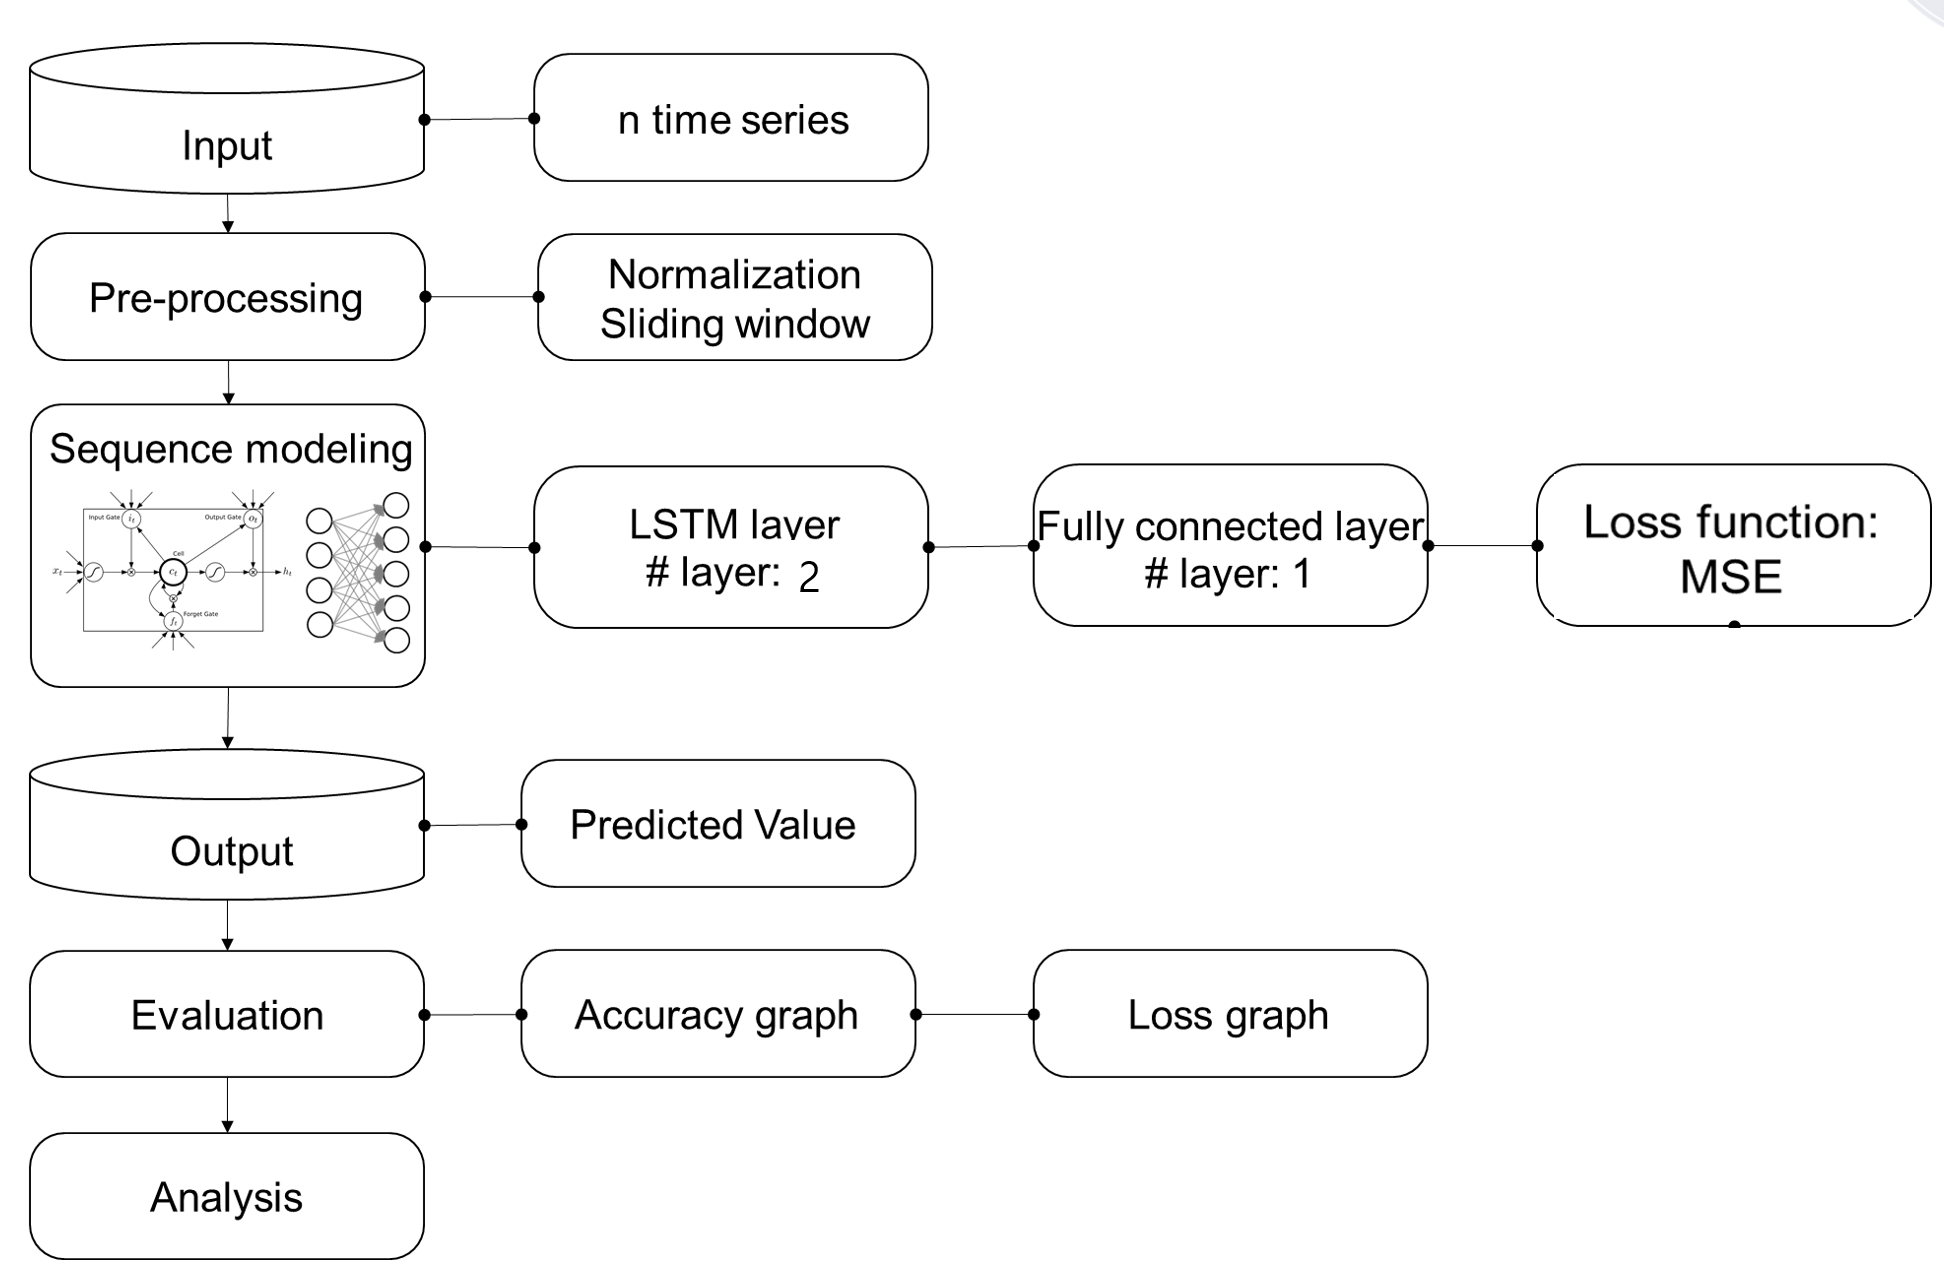

In [ ]:
import torch
import torch.nn as nn

class LSTMRegressor(nn.Module):
    """
    Many-to-One 아키텍처 기반의 LSTM Regression 모델.
    단변량 및 다변량 시계열의 연속형 변수 예측을 수행한다.
    """
    def __init__(self, input_size: int = 1, hidden_size: int = 64, num_layers: int = 2, dropout: float = 0.2): ## LSTM의 레이어는 직접 설정하거나 아래에서 구현하는 것이 아닌, pytorch 내장 함수로 바로 적용 가능
        super(LSTMRegressor, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # LSTM Layer
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        # Fully Connected Layer for Continuous Value Prediction
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x (torch.Tensor): Input tensor of shape (B, W, C)
        Returns:
            torch.Tensor: Output tensor of shape (B, 1)
        """
        # 은닉 상태(h_0)와 셀 상태(c_0)는 0으로 자동 초기화됨 (기본값)
        # out shape: (B, W, H_dim)
        out, _ = self.lstm(x)

        # Many-to-One: 시퀀스의 마지막 타임스텝(t=W)의 Hidden State 추출
        last_hidden_state = out[:, -1, :]  # shape: (B, H_dim)

        # 선형 변환을 통한 최종 예측값 산출
        predictions = self.fc(last_hidden_state)  # shape: (B, 1)

        return predictions

## 학습 루프 구현 및 $\mathcal{L}_{MSE}$ 최적화 시각화 (RNN vs. LSTM 비교 분석)

최적화 목적 함수로는 $\mathcal{L}_{MSE}$

금융 시계열의 장기 의존성(Long-term Dependency) 학습 성능을 비교하기 위해 Gating 메커니즘이 배제된 표준 RNN(Vanilla RNN) 아키텍처와 비교

시퀀스 길이가 60($W=60$)에 달할 때 표준 RNN에서 발생하는 기울기 소실(Vanishing Gradient) 현상을 확인한다.

### Vanilla RNN 아키텍처 정의 (비교군)

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np


class RNNRegressor(nn.Module):
    def __init__(self, input_size: int = 1, hidden_size: int = 64, num_layers: int = 2, dropout: float = 0.2):
        super(RNNRegressor, self).__init__()
        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out, _ = self.rnn(x)
        last_hidden_state = out[:, -1, :]
        return self.fc(last_hidden_state)

### 하드웨어 가속기 설정 및 모델 인스턴스화

In [9]:
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Target execution device: {device}")

# 동일한 파라미터 조건(Hidden=64, Layers=2)으로 두 모델 초기화
lstm_model = LSTMRegressor(input_size=1, hidden_size=64, num_layers=2, dropout=0.2).to(device) ## 모델 구조는 여기서 변경 가능
rnn_model = RNNRegressor(input_size=1, hidden_size=64, num_layers=2, dropout=0.2).to(device)

criterion = nn.MSELoss()
# 최적화 기법: Adam (Weight Decay를 통한 정규화 추가 가능)
lstm_optimizer = optim.Adam(lstm_model.parameters(), lr=1e-3) ## training 파라미터는 여기서 변경 가능
rnn_optimizer = optim.Adam(rnn_model.parameters(), lr=1e-3)

Target execution device: cuda


NameError: name 'LSTMRegressor' is not defined

### 범용 학습 및 검증 파이프라인

In [8]:
def train_and_evaluate(
    model: nn.Module,
    optimizer: optim.Optimizer,
    train_loader: DataLoader,
    test_loader: DataLoader,
    epochs: int = 50
) -> dict:
    history = {'train_loss': [], 'test_loss': []}

    for epoch in range(epochs):
        # Training Phase
        model.train()
        train_loss_accum = 0.0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            predictions = model(X_batch)
            loss = criterion(predictions, y_batch)
            loss.backward()

            # Gradient Clipping (Exploding Gradient 억제)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            train_loss_accum += loss.item() * X_batch.size(0)

        epoch_train_loss = train_loss_accum / len(train_loader.dataset)
        history['train_loss'].append(epoch_train_loss)

        # Validation Phase
        model.eval()
        test_loss_accum = 0.0
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                predictions = model(X_batch)
                loss = criterion(predictions, y_batch)
                test_loss_accum += loss.item() * X_batch.size(0)

        epoch_test_loss = test_loss_accum / len(test_loader.dataset)
        history['test_loss'].append(epoch_test_loss)

        if (epoch + 1) % 10 == 0:
            print(f"Epoch [{epoch+1}/{epochs}] | Train loss: {epoch_train_loss:.4f} | Test loss: {epoch_test_loss:.4f}")

    return history

NameError: name 'nn' is not defined

### 모델 학습 실행

In [ ]:
EPOCHS = 50
print("--- Training LSTM Model ---")
lstm_history = train_and_evaluate(lstm_model, lstm_optimizer, train_loader, test_loader, epochs=EPOCHS)

print("\n--- Training Vanilla RNN Model ---")
rnn_history = train_and_evaluate(rnn_model, rnn_optimizer, train_loader, test_loader, epochs=EPOCHS)

--- Training LSTM Model ---
Epoch [10/50] | Train loss: 0.0005 | Test loss: 0.0023
Epoch [20/50] | Train loss: 0.0004 | Test loss: 0.0013
Epoch [30/50] | Train loss: 0.0005 | Test loss: 0.0012
Epoch [40/50] | Train loss: 0.0005 | Test loss: 0.0010
Epoch [50/50] | Train loss: 0.0004 | Test loss: 0.0009

--- Training Vanilla RNN Model ---
Epoch [10/50] | Train loss: 0.0008 | Test loss: 0.0019
Epoch [20/50] | Train loss: 0.0004 | Test loss: 0.0010
Epoch [30/50] | Train loss: 0.0004 | Test loss: 0.0008
Epoch [40/50] | Train loss: 0.0004 | Test loss: 0.0035
Epoch [50/50] | Train loss: 0.0004 | Test loss: 0.0022


### 최적화 과정(Loss) 및 예측 결과 시각화

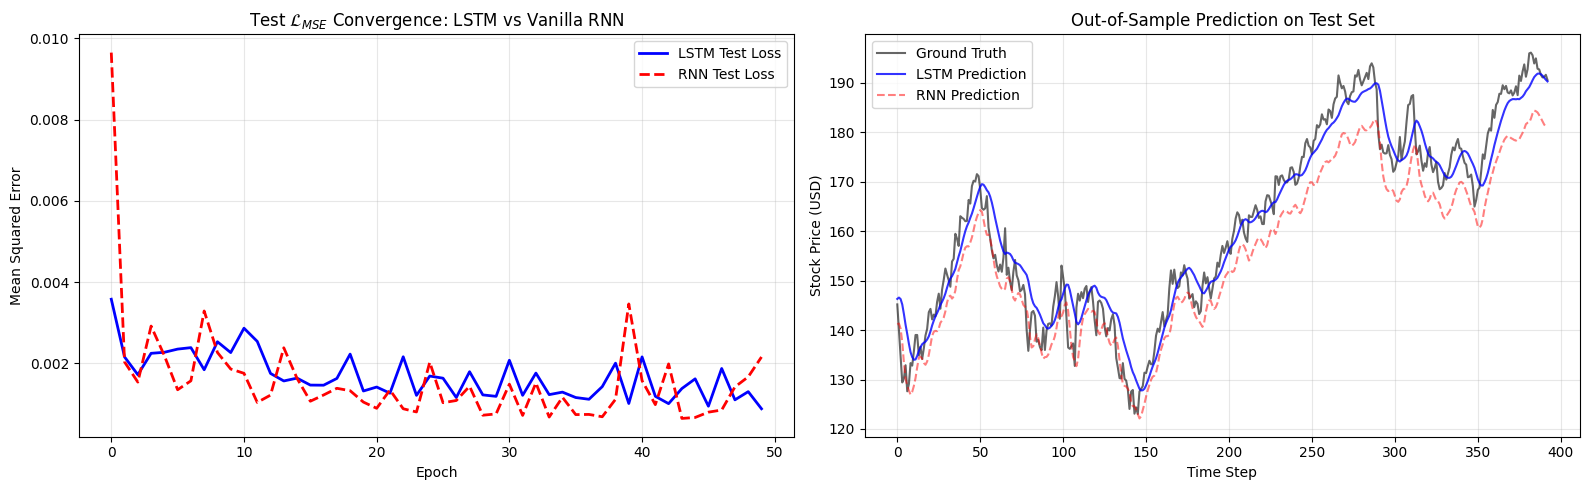

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 5-1. Loss Convergence Comparison
axes[0].plot(lstm_history['test_loss'], label='LSTM Test Loss', color='blue', linewidth=2)
axes[0].plot(rnn_history['test_loss'], label='RNN Test Loss', color='red', linestyle='--', linewidth=2)
axes[0].set_title(r"Test $\mathcal{L}_{MSE}$ Convergence: LSTM vs Vanilla RNN")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Mean Squared Error")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 5-2. Test Set Prediction Comparison (Inverse Transform)
# 성능 검증을 위해 Test 데이터셋에 대한 스케일 복원(Inverse Transform) 후 실제 스케일 예측
def get_predictions(model: nn.Module, loader: DataLoader) -> np.ndarray:
    model.eval()
    preds = []
    with torch.no_grad():
        for X_batch, _ in loader:
            X_batch = X_batch.to(device)
            preds.append(model(X_batch).cpu().numpy())
    return np.concatenate(preds, axis=0)

# 이전에 선언된 price_scaler 활용
lstm_preds_scaled = get_predictions(lstm_model, test_loader)
rnn_preds_scaled = get_predictions(rnn_model, test_loader)
actual_scaled = y_test_seq

lstm_preds_real = price_scaler.inverse_transform(lstm_preds_scaled)
rnn_preds_real = price_scaler.inverse_transform(rnn_preds_scaled)
actual_real = price_scaler.inverse_transform(actual_scaled)

axes[1].plot(actual_real, label='Ground Truth', color='black', alpha=0.6)
axes[1].plot(lstm_preds_real, label='LSTM Prediction', color='blue', alpha=0.8)
axes[1].plot(rnn_preds_real, label='RNN Prediction', color='red', alpha=0.5, linestyle='--')
axes[1].set_title("Out-of-Sample Prediction on Test Set")
axes[1].set_xlabel("Time Step")
axes[1].set_ylabel("Stock Price (USD)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Sentence Classification via LSTM

본 파트는 이산형(Discrete) 자연어 데이터를 처리하여 텍스트의 감성(긍정/부정)을 이진 분류(Binary Classification)하는 파이프라인을 구축한다.

Section 1에서 다룬 시계열 데이터가 연속적 차원 공간에서의 추세를 모델링했다면, 자연어 처리는 고정된 Vocabulary 내 이산적 토큰들의 시퀀스 $X = {w_1, w_2, \dots, w_T}$를 입력으로 받아 특정 클래스 $c \in {0, 1}$에 대한 사후 확률 $P(c|X)$를 추정하는 문제로 정의된다.

순환 신경망(RNN/LSTM)은 가변 길이(Variable-length) 시퀀스를 처리할 수 있으나, 미니 배치(Mini-batch) 연산을 위해서는 최대 시퀀스 길이에 맞춘 패딩(Padding)이 요구된다.

따라서 모델 아키텍처 설계 및 텐서 변환 이전에 탐색적 데이터 분석(EDA)을 통해 토큰 길이의 분포를 파악하고, 아웃라이어(Outlier)를 통제하여 연산 효율성과 메모리 최적화를 달성해야 한다. 이 과정은 후속 텍스트 전처리 및 $\mathcal{L}_{CE}$ 최적화의 기반이 된다.

![image](https://media.springernature.com/m685/springer-static/image/art%3A10.1038%2Fs41598-020-71450-8/MediaObjects/41598_2020_71450_Fig1_HTML.png)



## 자연어 데이터셋 로드 및 EDA

한국어 텍스트 감성 분석의 표준 벤치마크인 NSMC (Naver Sentiment Movie Corpus) 데이터셋을 활용한다.

본 데이터셋은 리뷰 텍스트와 함께 0(부정) 또는 1(긍정)의 Label을 포함한다.

결측치(Missing Values) 및 중복 데이터(Duplicates) 제거는 텍스트 분류 성능의 하한선(Lower Bound)을 결정하는 필수적인 전처리 과정이다.

또한, 각 리뷰의 텍스트 길이를 분석하여, 절단(Truncation) 및 패딩(Padding)의 기준이 되는 임계치(Threshold Length)를 경험적으로 도출한다.

In [ ]:
import urllib.request
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def load_and_clean_nsmc(url: str) -> pd.DataFrame:
    """
    지정된 URL에서 NSMC 데이터를 로드하고 결측치 및 중복을 제거한다.
    """
    file_name = url.split('/')[-1]
    urllib.request.urlretrieve(url, filename=file_name)

    df = pd.read_table(file_name)

    # 데이터 정제 (결측치 및 중복 제거)
    initial_len = len(df)
    df.drop_duplicates(subset=['document'], inplace=True)
    df.dropna(how='any', inplace=True)

    print(f"[{file_name}] Data Load & Clean: {initial_len} -> {len(df)} rows.")
    return df

### 데이터셋 다운로드 및 로드

In [ ]:
train_url = "https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt"
test_url = "https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt"

train_df = load_and_clean_nsmc(train_url)
test_df = load_and_clean_nsmc(test_url)

[ratings_train.txt] Data Load & Clean: 150000 -> 146182 rows.
[ratings_test.txt] Data Load & Clean: 50000 -> 49157 rows.


### 데이터셋 확인

In [ ]:
# 무작위로 확인할 샘플 개수 설정
n_samples = 5

# 1. 긍정 리뷰(label == 1) 샘플링
print("-" * 30)
print(f"[Positive Samples - {n_samples} examples]")
print("-" * 30)
positive_examples = train_df[train_df['label'] == 1].sample(n_samples, random_state=42)
for i, row in positive_examples.iterrows():
    print(f"Review: {row['document']}")
    print(f"Label: {row['label']} (Positive)")
    print("-" * 10)

# 2. 부정 리뷰(label == 0) 샘플링
print("\n" + "-" * 30)
print(f"[Negative Samples - {n_samples} examples]")
print("-" * 30)
negative_examples = train_df[train_df['label'] == 0].sample(n_samples, random_state=42)
for i, row in negative_examples.iterrows():
    print(f"Review: {row['document']}")
    print(f"Label: {row['label']} (Negative)")
    print("-" * 10)

------------------------------
[Positive Samples - 5 examples]
------------------------------
Review: 음악에 저절로 몸을 들썩이게 된다.
Label: 1 (Positive)
----------
Review: 유치하고 단순한 할리퀸이지만 그게 사랑스러워
Label: 1 (Positive)
----------
Review: 인류의 역사를 말하는 작품.
Label: 1 (Positive)
----------
Review: 잘보고있어요!! 이번주 화요일은 시험기간이라고 못봤어요.. 저 울음.. 엄마 혼자 봤어요..
Label: 1 (Positive)
----------
Review: 실화라는것에흥미를느껴봤다.역시동물나오는건슬퍼ㅠ뱀뱀죽엇을때너무슬펐다ㅠ0ㅠ
Label: 1 (Positive)
----------

------------------------------
[Negative Samples - 5 examples]
------------------------------
Review: 설정이 복잡하고 캐릭터가 죽어 있어 마지막 전에 질린다
Label: 0 (Negative)
----------
Review: 줄거리 진짜 꽝... 슈퍼가 보는맛에 버텼다...
Label: 0 (Negative)
----------
Review: 영화가 끝나갈무렵 범이가 칼맞고 쓰러졋을때 수경이가 발로 찾을때... 난 그장면이 제일 임팩트 잇는것같다!
Label: 0 (Negative)
----------
Review: 택시 시리즈의 수치.
Label: 0 (Negative)
----------
Review: 록키 6라... -_-;;
Label: 0 (Negative)
----------


### 클래스 불균형(Class Imbalance) 확인

In [ ]:
print("\n[Train Set Label Distribution]")
print(train_df['label'].value_counts(normalize=True))


[Train Set Label Distribution]
label
0    0.501717
1    0.498283
Name: proportion, dtype: float64


### 텍스트 시퀀스 길이 분석 (어절 단위 기반)

In [ ]:
# 형태소 분석 이전이므로, 공백 기준 분리(Whitespace Tokenization)를 임시 기준으로 사용함
train_df['length'] = train_df['document'].apply(lambda x: len(str(x).split()))

시각적인 확인을 위해 샘플 단어 설정

In [ ]:
sample_pos_text = "이 영화 정말 최고예요"
sample_neg_text = "진짜 시간 아깝네요 보지마세요"

어절 기반 분석 결과

### EDA 시각화

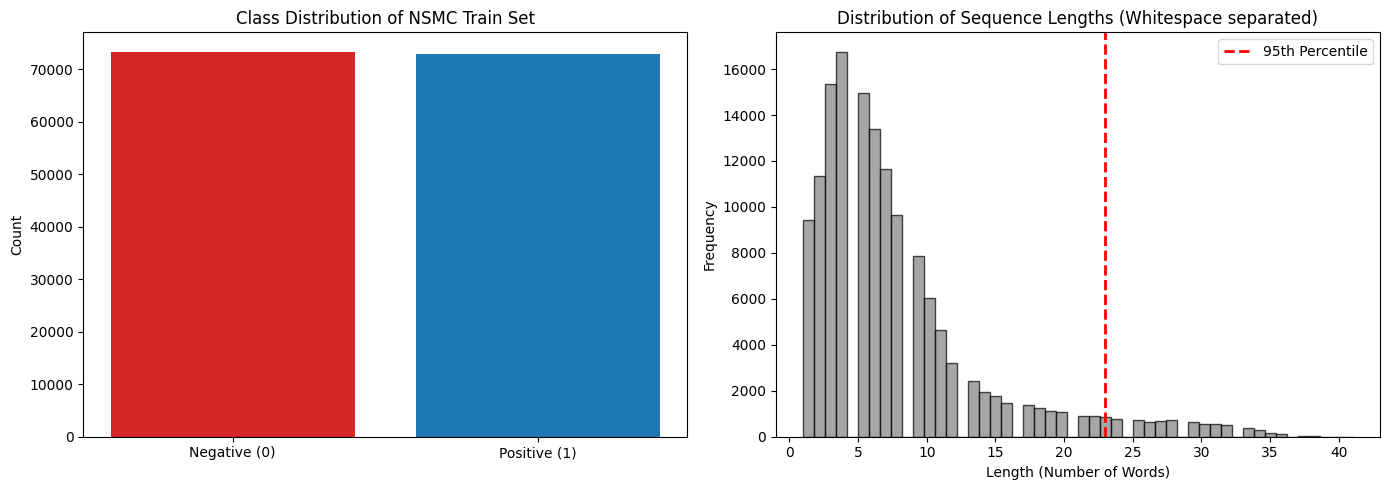

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Label Distribution
axes[0].bar(['Negative (0)', 'Positive (1)'], train_df['label'].value_counts().sort_index(), color=['#d62728', '#1f77b4'])
axes[0].set_title("Class Distribution of NSMC Train Set")
axes[0].set_ylabel("Count")

# Text Length Distribution
axes[1].hist(train_df['length'], bins=50, color='gray', edgecolor='black', alpha=0.7)
axes[1].set_title("Distribution of Sequence Lengths (Whitespace separated)")
axes[1].set_xlabel("Length (Number of Words)")
axes[1].set_ylabel("Frequency")
axes[1].axvline(np.percentile(train_df['length'], 95), color='red', linestyle='dashed', linewidth=2, label='95th Percentile') ## 95%에 레드 도트
axes[1].legend()

plt.tight_layout()
plt.show()

위 그림에서 약 95 길이만큼을 설정했다. (99%를 설정해도 무관함)

95% 데이터를 커버하는 길이를 확인 한 뒤 Padding 기준값으로 활용한다.

In [ ]:
optimal_max_len = int(np.percentile(train_df['length'], 95))
print(f"\nOptimal Max Sequence Length (covering 95% of data): {optimal_max_len}")


Optimal Max Sequence Length (covering 95% of data): 23


## 텍스트 전처리 (Vocab 생성, 정수 인코딩, Padding)

1. 자연어 텍스트는 이산적(Discrete) 심볼의 집합이다.

2. 신경망의 연산을 위해 텍스트 시퀀스 $X = {w_1, w_2, \dots, w_T}$를 연속형 벡터 공간으로 투영하기 위한 사전 단계로서, 각 토큰 $w_t$를 고유한 정수 인덱스 $i_t \in \mathbb{N}$로 매핑하는 정수 인코딩(Integer Encoding) 과정이 필수적이다. (tokenization 이라고도 함)

- chatgpt의 tokenization: https://platform.openai.com/tokenizer

3. 이 과정에서 훈련 데이터셋 기반의 어휘 집합(Vocabulary, $\mathcal{V}$)을 구축한다.


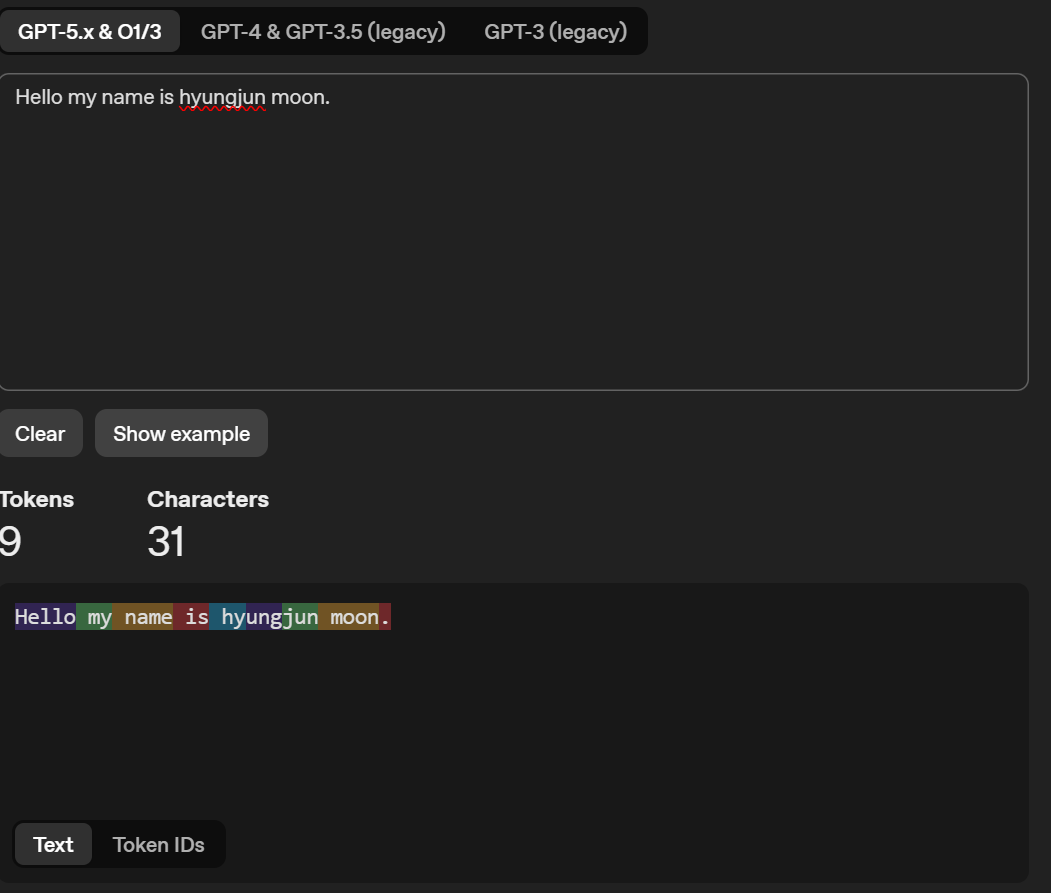

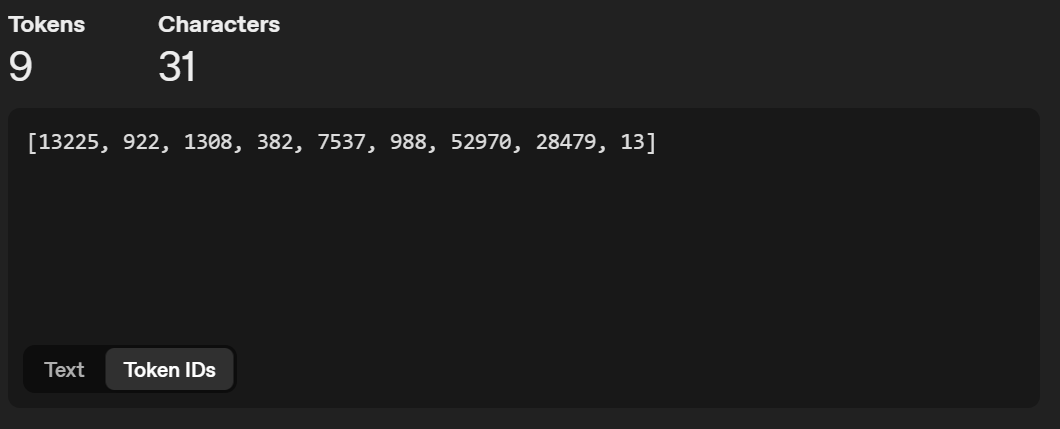

4. 희소 토큰(Rare tokens, 자주 보이지 않는 토큰)은 파라미터 공간을 불필요하게 확장하여 과적합(Overfitting)을 유발하므로, 출현 빈도가 임계치(min_freq) 미만인 토큰은 <UNK>(Unknown) 토큰으로 치환하여 OOV(Out-Of-Vocabulary) 문제에 대응한다.

5. 학습을 위해서는 시퀀스 길이를 정규화해야 한다. 앞선 EDA에서 도출한 임계 길이 $T_{max}$를 기준으로, 길이가 $T < T_{max}$인 시퀀스에는 <PAD> 토큰을 추가(Padding)하고, $T > T_{max}$인 시퀀스는 절단(Truncation)하여 차원을 통일한다.

In [ ]:
import numpy as np
import pandas as pd
from collections import Counter
from typing import List, Dict, Tuple

# 특수 토큰 정의 및 인덱스 할당
PAD_TOKEN, UNK_TOKEN = '<PAD>', '<UNK>'
PAD_IDX, UNK_IDX = 0, 1

### vocabulary를 만드는 함수 설정

In [ ]:
def build_vocabulary(corpus: pd.Series, min_freq: int = 2) -> Tuple[Dict[str, int], Dict[int, str]]:
    """
    훈련 말뭉치를 기반으로 Vocabulary를 구축한다.
    (주의: Data Leakage 방지를 위해 반드시 Train Set에 대해서만 수행해야 함)
    """
    counter = Counter()
    for text in corpus:
        # Part 2-1과 동일하게 공백 기반 토큰화 적용 (실제 연구에서는 Mecab, BPE 등 서브워드 토크나이저 권장)
        tokens = str(text).split()
        counter.update(tokens)

    # min_freq 이상 등장한 토큰만 필터링하여 Vocab 구성
    vocab_words = [PAD_TOKEN, UNK_TOKEN] + [word for word, freq in counter.items() if freq >= min_freq]

    word2idx = {word: idx for idx, word in enumerate(vocab_words)}
    idx2word = {idx: word for word, idx in word2idx.items()}

    return word2idx, idx2word

### 모든 text의 길이를 맞추기 위해 padding 함수 구성

In [ ]:
def encode_and_pad(
    corpus: pd.Series,
    word2idx: Dict[str, int],
    max_len: int
) -> np.ndarray:
    """
    텍스트를 정수 인덱스 시퀀스로 변환하고 max_len에 맞춰 Padding/Truncation을 수행한다.
    """
    encoded_corpus = []

    for text in corpus:
        tokens = str(text).split()
        # OOV 토큰은 UNK_IDX로 처리
        encoded = [word2idx.get(token, UNK_IDX) for token in tokens]

        # Truncation & Padding
        if len(encoded) >= max_len:
            encoded = encoded[:max_len]
        else:
            # Pre-padding 적용 (RNN 계열에서는 마지막 시점의 은닉 상태가 중요하므로 상황에 따라 Post-padding과 선택적 사용)
            encoded = [PAD_IDX] * (max_len - len(encoded)) + encoded

        encoded_corpus.append(encoded)

    return np.array(encoded_corpus, dtype=np.int64)

### Vocabulary 구축 (Train Set 기준)

In [ ]:
MIN_FREQ = 2 # 최소 두번 이상 등장해야 하도록 구성하기 ## 조정 가능한 파라미터
word2idx, idx2word = build_vocabulary(train_df['document'], min_freq=MIN_FREQ)
vocab_size = len(word2idx)
print(f"Vocabulary Size (min_freq={MIN_FREQ}): {vocab_size}")

Vocabulary Size (min_freq=2): 72856


전처리 과정 시각화 (Tokenization과 Word2idx)

In [ ]:
# 시각화 및 후속 단계 활용을 위한 샘플 선정
# (고정된 인덱스를 사용하거나 조건에 맞는 샘플을 명시적으로 추출)
sample_pos_text = "이 영화 정말 최고예요"
sample_neg_text = "진짜 시간 아깝네요 보지마세요"

def trace_transformation(texts: list, word2idx: dict):
    """
    텍스트가 토큰화 및 정수 인코딩되는 과정을 추적하여 리스트로 반환한다.
    """
    results = []
    for text in texts:
        # 1. Tokenization (공백 기준)
        tokens = str(text).split()

        # 2. Integer Encoding
        encoded = [word2idx.get(token, word2idx.get('<UNK>')) for token in tokens]

        results.append({
            "raw": text,
            "tokens": tokens,
            "encoded": encoded
        })
    return results

# 변환 수행
trace_samples = [sample_pos_text, sample_neg_text]
transformation_log = trace_transformation(trace_samples, word2idx)

# 시각화 출력 (컬럼 확장 구조)
print(f"{'Step / Sample':<20} | {'Positive Example':<30} | {'Negative Example':<30}")
print("-" * 85)
print(f"{'1. Raw Text':<20} | {transformation_log[0]['raw']:<30} | {transformation_log[1]['raw']:<30}")
print(f"{'2. Tokenized':<20} | {str(transformation_log[0]['tokens']):<30} | {str(transformation_log[1]['tokens']):<30}")
print(f"{'3. Word2Idx':<20} | {str(transformation_log[0]['encoded']):<30} | {str(transformation_log[1]['encoded']):<30}")

Step / Sample        | Positive Example               | Negative Example              
-------------------------------------------------------------------------------------
1. Raw Text          | 이 영화 정말 최고예요                   | 진짜 시간 아깝네요 보지마세요              
2. Tokenized         | ['이', '영화', '정말', '최고예요']      | ['진짜', '시간', '아깝네요', '보지마세요'] 
3. Word2Idx          | [155, 37, 84, 57129]           | [4, 2802, 828, 4065]          


### 정수 인코딩 및 패딩 적용

In [ ]:
# Part 2-1에서 도출한 optimal_max_len 사용 (예: 25로 가정)
MAX_LEN = optimal_max_len if 'optimal_max_len' in locals() else 25

In [ ]:
X_train_pad = encode_and_pad(train_df['document'], word2idx, MAX_LEN)
X_test_pad = encode_and_pad(test_df['document'], word2idx, MAX_LEN)

y_train = train_df['label'].values
y_test = test_df['label'].values

In [ ]:
# 3. 텐서 형상 검증
print(f"X_train_pad shape: {X_train_pad.shape}") # Expected: (N_train, MAX_LEN)
print(f"y_train shape: {y_train.shape}")         # Expected: (N_train,)
print(f"X_test_pad shape: {X_test_pad.shape}")   # Expected: (N_test, MAX_LEN)

# 샘플 데이터 인코딩 결과 확인
sample_idx = 4
print(f"\nOriginal text: {train_df['document'].iloc[sample_idx]}")
print(f"Encoded & Padded: {X_train_pad[sample_idx]}")

X_train_pad shape: (146182, 23)
y_train shape: (146182,)
X_test_pad shape: (49157, 23)

Original text: 사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 던스트가 너무나도 이뻐보였다
Encoded & Padded: [ 0  0  0  0  0  0  0  0  0  0  0  0  1 12 13 14  1  1 15 16  1 17  1]


전처리 과정 시각화

In [ ]:
import torch
def trace_full_transformation(texts: list, word2idx: dict, max_len: int):
    """
    텍스트가 정수 인코딩을 거쳐 패딩까지 완료되는 전 과정을 추적한다.
    """
    results = []
    for text in texts:
        # 1. Tokenization
        tokens = str(text).split()

        # 2. Integer Encoding
        encoded = [word2idx.get(token, UNK_IDX) for token in tokens]

        # 3. Padding (Pre-padding)
        if len(encoded) >= max_len:
            padded = encoded[:max_len]
        else:
            padded = [PAD_IDX] * (max_len - len(encoded)) + encoded

        results.append({
            "raw": text,
            "tokens": tokens,
            "encoded": encoded,
            "padded": padded
        })
    return results

# 샘플 데이터 변환 수행
sample_pos_text = "이 영화 정말 최고예요"
sample_neg_text = "진짜 시간 아깝네요 보지마세요"
trace_samples = [sample_pos_text, sample_neg_text]

full_log = trace_full_transformation(trace_samples, word2idx, MAX_LEN)

# 시각화 출력 (컬럼 확장 구조)
print(f"{'Step / Sample':<20} | {'Positive Example':<35} | {'Negative Example':<35}")
print("-" * 100)
print(f"{'1. Raw Text':<20} | {full_log[0]['raw']:<35} | {full_log[1]['raw']:<35}")
print(f"{'2. Tokenized':<20} | {str(full_log[0]['tokens']):<35} | {str(full_log[1]['tokens']):<35}")
print(f"{'3. Word2Idx':<20} | {str(full_log[0]['encoded']):<35} | {str(full_log[1]['encoded']):<35}")
print(f"{'4. Padding (Input)':<20} | {str(full_log[0]['padded']):<35} | {str(full_log[1]['padded']):<35}")

# 최종 Tensor 형태 확인 (Batch 차원 포함)
input_tensor = torch.tensor([full_log[0]['padded'], full_log[1]['padded']], dtype=torch.long)
print(f"\nFinal Input Tensor Shape: {input_tensor.shape}") # Expected: (2, MAX_LEN)

Step / Sample        | Positive Example                    | Negative Example                   
----------------------------------------------------------------------------------------------------
1. Raw Text          | 이 영화 정말 최고예요                        | 진짜 시간 아깝네요 보지마세요                   
2. Tokenized         | ['이', '영화', '정말', '최고예요']           | ['진짜', '시간', '아깝네요', '보지마세요']      
3. Word2Idx          | [155, 37, 84, 57129]                | [4, 2802, 828, 4065]               
4. Padding (Input)   | [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 155, 37, 84, 57129] | [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4, 2802, 828, 4065]

Final Input Tensor Shape: torch.Size([2, 23])


## PyTorch Text DataLoader 구축

전처리 파이프라인을 통해 $T_{max}$ 길이로 정규화된 이산형 정수 시퀀스(Discrete Integer Sequence) 행렬을 PyTorch의 미니 배치(Mini-batch) 연산에 최적화된 형태로 변환한다.

In [ ]:
import torch
from torch.utils.data import TensorDataset, DataLoader

# 1. Numpy 배열을 PyTorch Tensor로 변환 및 데이터 타입 강제
# nn.Embedding 연산을 위해 입력 X는 반드시 long 타입(int64)이어야 함
X_train_tensor = torch.tensor(X_train_pad, dtype=torch.long)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

X_test_tensor = torch.tensor(X_test_pad, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# 2. TensorDataset 구축
# 메모리에 모든 텐서가 적재된 상태이므로 커스텀 Dataset 클래스 대신 TensorDataset을 활용하여 오버헤드 최소화
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [ ]:
# 3. DataLoader 인스턴스화
# 텍스트 시퀀스 처리 시 임베딩 계층 및 LSTM의 메모리 점유율이 높으므로, GPU VRAM 제약에 따라 BATCH_SIZE 조절 필요
BATCH_SIZE = 128

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,          # 에포크마다 미니 배치 $\mathcal{B}$ 구성 무작위화
    drop_last=True,        # 학습 안정성을 위해 불완전한 크기의 마지막 배치 버림
    pin_memory=True        # Host to Device 전송 병목 완화
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False,
    pin_memory=True
)

In [ ]:
# 4. DataLoader 메모리 매핑 및 텐서 형상 검증
sample_X, sample_y = next(iter(train_loader))
print(f"Batch Text Sequence (X) shape: {sample_X.shape}") # Expected: (128, MAX_LEN)
print(f"Batch Text Sequence (X) dtype: {sample_X.dtype}") # Expected: torch.int64
print(f"Batch Label (y) shape: {sample_y.shape}")         # Expected: (128,)
print(f"Batch Label (y) dtype: {sample_y.dtype}")         # Expected: torch.int64

Batch Text Sequence (X) shape: torch.Size([128, 23])
Batch Text Sequence (X) dtype: torch.int64
Batch Label (y) shape: torch.Size([128])
Batch Label (y) dtype: torch.int64


## Word Embedding이 결합된 LSTM Classification 모델 설계

### 워드 임베딩(Word Embedding)

컴퓨터는 자연어 텍스트를 있는 그대로 연산할 수 없다.

따라서 단어를 수학적 벡터(Vector)로 변환하는 과정이 필요하며, 이는 역사적으로 3단계를 거쳐 발전해 왔다.

#### 1단계: 정수 인코딩 (Integer Encoding) - 단어에 고유 번호표 부여

가장 직관적인 방법은 사전(Vocabulary)을 구축하고 각 단어에 고유한 정수 번호를 부여하는 것이다.

- 사과 = 1

- 바나나 = 2

- 고양이 = 3

**문제점**: 컴퓨터는 숫자의 '크기'를 관계로 오해한다. '사과(1) + 1 = 바나나(2)'라는 잘못된 수학적 연관성을 딥러닝 모델이 학습할 위험이 존재한다.

#### 2단계: 원-핫 인코딩 (One-Hot Encoding) - 단어를 독립된 차원으로 분리

숫자의 크기가 가지는 오해를 풀기 위해, 전체 단어 사전의 크기(예: 10,000개)만큼의 0으로 채워진 텐서를 생성하고, 해당 단어의 인덱스 위치만 1로 표시(Hot)한다.

- 사과 = [1, 0, 0, 0, ..., 0]

- 바나나 = [0, 1, 0, 0, ..., 0]

- 고양이 = [0, 0, 1, 0, ..., 0]

한계점

1. 차원의 저주 (Curse of Dimensionality): 단어가 10만 개라면 벡터의 차원도 10만이 되며, 99.9%가 0으로 채워져 메모리 낭비가 극심해진다.
2. 단어 간의 단절 (Orthogonality): 사과와 바나나는 과일이라는 의미적 공통점이 존재하지만, 두 원-핫 벡터를 내적(Dot Product)하면 항상 0이 된다. 즉, 컴퓨터에게 모든 단어는 서로 완전히 무관한(직교하는) 독립적 존재로 인식된다.

#### 3단계: 워드 임베딩 (Word Embedding) - 의미를 담은 밀집 벡터(Dense Vector) 공간

원-핫 인코딩의 희소성(Sparsity) 문제를 해결하기 위해, 단어들을 훨씬 저차원(예: 128차원)의 '벡터 공간(Vector Space)' 위로 사영(Projection)하여 배치한다. 이를 워드 임베딩이라 한다.

In [ ]:
# 1. 자연어 시퀀스
text = ["사과", "바나나", "고양이"]

# 단계 1: Integer Encoding (단순 번호표)
# 숫자의 크기가 모델에 잘못된 선형적 관계를 학습시킬 수 있음.
integer_encoded = [1, 2, 3]

# 단계 2: One-Hot Encoding (희소 벡터 - Sparse Vector)
# 단어 사전 크기가 10,000이라고 가정할 때, $\mathbb{R}^{10000}$ 차원의 벡터가 생성됨.
# 단어 간 내적(Dot Product)이 항상 0이 되어 문맥적 유사도를 파악할 수 없음.
one_hot_apple  = [1, 0, 0, 0, 0, 0] # (생략)
one_hot_banana = [0, 1, 0, 0, 0, 0] # (생략)
one_hot_cat    = [0, 0, 1, 0, 0, 0] # (생략)

# 단계 3: Word Embedding (밀집 벡터 - Dense Vector)
# 모델이 $\mathcal{L}_{CE}$를 최소화하는 역전파(Backpropagation) 과정을 통해
# 각 단어의 잠재적 특성(Latent Feature) 값을 스스로 학습함.
# 예: [단맛의 정도, 크기, 동물성] 차원이라고 가정한 직관적 예시
embedded_apple  = [ 0.9,  0.2, -0.8]
embedded_banana = [ 0.8,  0.3, -0.9]
embedded_cat    = [-0.1,  0.4,  0.9]

# 결론:
# 임베딩 공간에서는 사과(0.9, 0.2, -0.8)와 바나나(0.8, 0.3, -0.9)의
# 벡터 유클리디안 거리(Euclidean Distance)가 가깝게 분포하므로,
# 딥러닝 모델이 문맥적, 의미론적 유사성을 수학적으로 연산할 수 있게 된다.

Embedding 시각화

In [ ]:
import torch
import torch.nn as nn
import pandas as pd

sample_pos_text = "이 영화 정말 최고예요"
sample_neg_text = "진짜 시간 아깝네요 보지마세요"
samples = [sample_pos_text, sample_neg_text]

# 2. 임베딩 레이어 초기화 (가중치 고정)
# vocab_size는 이전 섹션에서 구축된 값을 참조함
dummy_embedding = nn.Embedding(num_embeddings=vocab_size, embedding_dim=EMBED_DIM, padding_idx=PAD_IDX)

def trace_entire_pipeline(texts, word2idx, embedding_layer, max_len):
    pipeline_results = []
    embedding_layer.eval()

    for text in texts:
        # Step 1: Tokenization
        tokens = str(text).split()

        # Step 2: Word2Idx (Integer Encoding)
        encoded = [word2idx.get(token, UNK_IDX) for token in tokens]

        # Step 3: Padding (Pre-padding)
        if len(encoded) >= max_len:
            padded = encoded[:max_len]
        else:
            padded = [PAD_IDX] * (max_len - len(encoded)) + encoded

        # Step 4: Embedding Projection
        input_tensor = torch.tensor(padded, dtype=torch.long).unsqueeze(0)
        with torch.no_grad():
            embedded = embedding_layer(input_tensor) # (1, max_len, embed_dim)

        # 시각화를 위해 리스트 형태로 저장
        pipeline_results.append({
            "raw": text,
            "tokens": tokens,
            "encoded": encoded,
            "padded": padded,
            "embedded": embedded[0].numpy().tolist() # (max_len, embed_dim)
        })
    return pipeline_results

# 파이프라인 실행
results = trace_entire_pipeline(samples, word2idx, dummy_embedding, MAX_LEN)

# 3. 통합 시각화 출력
print(f"{'Pipeline Stage':<20} | {'Positive Sample (1)':<45} | {'Negative Sample (0)':<45}")
print("-" * 115)

# Raw, Tokens, Encoded, Padded 출력
stages = [("1. Raw Text", "raw"), ("2. Tokenized", "tokens"), ("3. Word2Idx", "encoded"), ("4. Padding", "padded")]
for label, key in stages:
    print(f"{label:<20} | {str(results[0][key]):<45} | {str(results[1][key]):<45}")

print("-" * 115)
print(f"{'5. Embedding Projection (Vector Space)':^115}")
print("-" * 115)

# Embedding Vector 출력 (각 타임스텝별로 출력)
for t in range(MAX_LEN):
    pos_vec = [round(v, 3) for v in results[0]['embedded'][t]]
    neg_vec = [round(v, 3) for v in results[1]['embedded'][t]]
    token_p = results[0]['padded'][t]
    token_n = results[1]['padded'][t]

    # 0(PAD)인 경우 시각적 구분을 위해 표시
    p_label = f"IDX:{token_p}" if token_p != 0 else "PAD"
    n_label = f"IDX:{token_n}" if token_n != 0 else "PAD"

    print(f"Time {t} ({p_label:>7}) | {str(pos_vec):<45} | ({n_label:>7}) {str(neg_vec):<45}")

Pipeline Stage       | Positive Sample (1)                           | Negative Sample (0)                          
-------------------------------------------------------------------------------------------------------------------
1. Raw Text          | 이 영화 정말 최고예요                                  | 진짜 시간 아깝네요 보지마세요                             
2. Tokenized         | ['이', '영화', '정말', '최고예요']                     | ['진짜', '시간', '아깝네요', '보지마세요']                
3. Word2Idx          | [155, 37, 84, 57129]                          | [4, 2802, 828, 4065]                         
4. Padding           | [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 155, 37, 84, 57129] | [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4, 2802, 828, 4065]
-------------------------------------------------------------------------------------------------------------------
                                      5. Embedding Projection (Vector Space)                                       
---

## 모델 설계

Padding Index Ignorance: 연산 효율성을 위해 추가된 <PAD> 토큰은 의미적 가치가 없으므로, nn.Embedding 선언 시 padding_idx를 명시하여 해당 인덱스의 기울기(Gradient) 업데이트를 차단해야 한다.

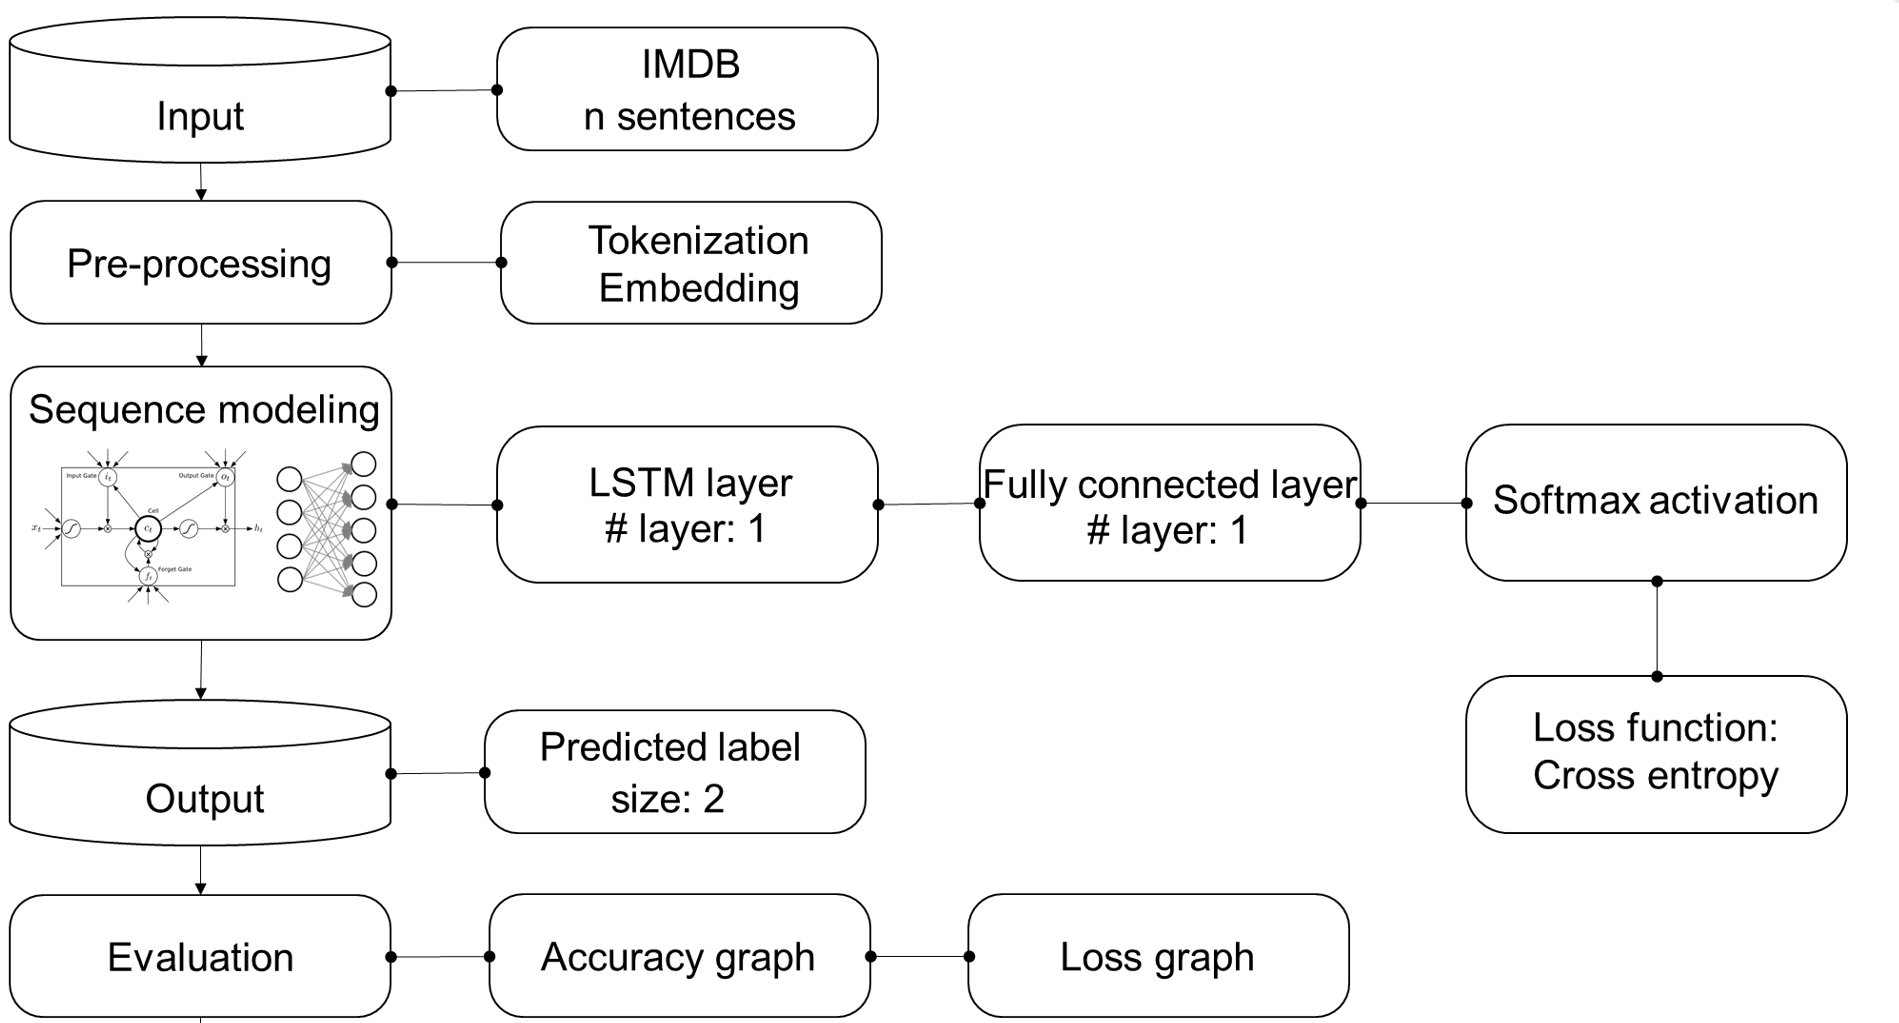

In [ ]:
import torch
import torch.nn as nn

class LSTMClassifier(nn.Module):
    """
    텍스트 분류를 위한 Word Embedding 및 LSTM 결합 아키텍처.
    N-way Classification으로의 확장을 고려하여 출력 차원을 num_classes로 일반화함.
    """
    def __init__(
        self,
        vocab_size: int,
        embed_dim: int = 128,
        hidden_dim: int = 256,
        num_classes: int = 2,
        num_layers: int = 2,
        dropout: float = 0.3,
        pad_idx: int = 0
    ):
        super(LSTMClassifier, self).__init__()

        # 1. Word Embedding Layer
        # pad_idx에 해당하는 임베딩 벡터는 0으로 초기화되며, 학습 과정에서 업데이트되지 않음
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embed_dim,
            padding_idx=pad_idx
        )

        # 2. LSTM Layer
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        # 3. Classifier (Fully Connected Layer)
        # Regularization을 위한 Dropout 추가
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x (torch.Tensor): Integer encoded sequence of shape (B, T_max)
        Returns:
            torch.Tensor: Class logits of shape (B, C)
        """
        # (B, T_max) -> (B, T_max, D_emb)
        embedded = self.embedding(x)

        # out: (B, T_max, H_dim)
        # hidden: (num_layers, B, H_dim)
        # cell: (num_layers, B, H_dim)
        out, (hidden, cell) = self.lstm(embedded)

        # Many-to-One: 마지막 레이어의 최종 Hidden State 추출
        # 형태: (B, H_dim)
        last_hidden = hidden[-1, :, :]

        # Dropout 적용 후 선형 사영을 통해 Logit 도출
        # (B, H_dim) -> (B, C)
        logits = self.fc(self.dropout(last_hidden))

        return logits

## 학습 루프 구현 및 모델 학습

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

# 1. 하드웨어 디바이스 할당 및 모델 초기화
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')

# Part 2-2, 2-4에서 정의된 변수 재사용 가정 (vocab_size, PAD_IDX 등)
model = LSTMClassifier(
    vocab_size=vocab_size,
    embed_dim=128,
    hidden_dim=256,
    num_classes=2,
    num_layers=2,
    dropout=0.3,
    pad_idx=PAD_IDX
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5) # L2 Regularization 추가

# 2. 모델 학습 및 평가 파이프라인
def train_and_eval_classifier(
    model: nn.Module,
    train_loader: torch.utils.data.DataLoader,
    test_loader: torch.utils.data.DataLoader,
    epochs: int = 10
):
    for epoch in range(epochs):
        # Training Phase
        model.train()
        train_loss, correct_train, total_train = 0.0, 0, 0

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()

            # Gradient Clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()

            train_loss += loss.item() * X_batch.size(0)
            preds = torch.argmax(logits, dim=1)
            correct_train += (preds == y_batch).sum().item()
            total_train += y_batch.size(0)

        train_acc = correct_train / total_train

        # Validation Phase
        model.eval()
        test_loss, correct_test, total_test = 0.0, 0, 0
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                logits = model(X_batch)
                loss = criterion(logits, y_batch)

                test_loss += loss.item() * X_batch.size(0)
                preds = torch.argmax(logits, dim=1)
                correct_test += (preds == y_batch).sum().item()
                total_test += y_batch.size(0)

        test_acc = correct_test / total_test

        print(f"Epoch [{epoch+1}/{epochs}] "
              f"Train : {train_loss/total_train:.4f}, Acc: {train_acc:.4f} | "
              f"Test : {test_loss/total_test:.4f}, Acc: {test_acc:.4f}")

# 3. 모델 학습 수행
EPOCHS = 5
print("--- Training Sentence Classification Model ---")
train_and_eval_classifier(model, train_loader, test_loader, epochs=EPOCHS)

--- Training Sentence Classification Model ---
Epoch [1/5] Train : 0.5624, Acc: 0.6869 | Test : 0.4865, Acc: 0.7450
Epoch [2/5] Train : 0.4283, Acc: 0.7885 | Test : 0.4337, Acc: 0.7835
Epoch [3/5] Train : 0.3519, Acc: 0.8342 | Test : 0.4364, Acc: 0.7869
Epoch [4/5] Train : 0.2998, Acc: 0.8619 | Test : 0.4489, Acc: 0.7853
Epoch [5/5] Train : 0.2621, Acc: 0.8788 | Test : 0.4763, Acc: 0.7789


학습이 완료된 이후에는, 훈련 데이터 분포 밖의(Out-of-Distribution) 임의의 자연어 문장에 대해 전처리 파이프라인(Tokenization $\rightarrow$ Integer Encoding $\rightarrow$ Padding)을 동일하게 적용하여 모델의 추론(Inference) 결과를 검증한다.

In [ ]:
# 4. 임의의 문장에 대한 추론(Inference) 함수 구현
def predict_sentiment(sentence: str, model: nn.Module, word2idx: dict, max_len: int) -> float:
    """
    단일 문장을 입력받아 전처리를 수행하고 긍정(1) 클래스에 대한 사후 확률을 반환한다.
    """
    model.eval()

    # Text Preprocessing (동일한 Tokenization 적용)
    tokens = sentence.split()
    encoded = [word2idx.get(token, word2idx.get('<UNK>')) for token in tokens]

    # Padding
    if len(encoded) >= max_len:
        padded = encoded[:max_len]
    else:
        padded = [word2idx.get('<PAD>')] * (max_len - len(encoded)) + encoded

    # Tensor Transformation
    tensor_input = torch.tensor(padded, dtype=torch.long).unsqueeze(0).to(device) # (1, T_max)

    with torch.no_grad():
        logits = model(tensor_input)
        # Logit을 확률로 변환하기 위해 Softmax 적용
        probs = torch.softmax(logits, dim=1)
        positive_prob = probs[0][1].item() # 긍정(인덱스 1) 확률 추출

    return positive_prob

## $\mathcal{L}_{CE}$ 기반 예측 테스트

In [ ]:
# 5. 추론 테스트
sample_sentences = [
    "이 영화 정말 지루하고 시간 아깝네요",
    "배우들의 연기력이 돋보이는 훌륭한 작품이었습니다",
    "기대 안 하고 봤는데 생각보다 흥미진진함"
]

print("\n--- Inference Test ---")
for text in sample_sentences:
    pos_prob = predict_sentiment(text, model, word2idx, MAX_LEN)
    prediction = "Positive" if pos_prob > 0.5 else "Negative"
    print(f"Input: {text}")
    print(f"Prediction: {prediction} (Positive Probability: {pos_prob:.4f})\n")


--- Inference Test ---
Input: 이 영화 정말 지루하고 시간 아깝네요
Prediction: Negative (Positive Probability: 0.0026)

Input: 배우들의 연기력이 돋보이는 훌륭한 작품이었습니다
Prediction: Positive (Positive Probability: 0.9946)

Input: 기대 안 하고 봤는데 생각보다 흥미진진함
Prediction: Positive (Positive Probability: 0.9524)

